In [26]:
import requests
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [19]:
!wget -O Cat.jpg "https://raw.githubusercontent.com/ProbablyItsSpirit/CSET340_Advanced_Computer_Vision/main/lab_7/Test_Images_Lab_7/Cat.jpg"
!wget -O penguine.jpg "https://raw.githubusercontent.com/ProbablyItsSpirit/CSET340_Advanced_Computer_Vision/main/lab_7/Test_Images_Lab_7/penguine.jpg"
!wget -O cameraman.jpg "https://raw.githubusercontent.com/ProbablyItsSpirit/CSET340_Advanced_Computer_Vision/main/lab_7/Test_Images_Lab_7/cameraman.jpg"

--2026-03-19 06:21:44--  https://raw.githubusercontent.com/ProbablyItsSpirit/CSET340_Advanced_Computer_Vision/main/lab_7/Test_Images_Lab_7/Cat.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46718 (46K) [image/jpeg]
Saving to: ‘Cat.jpg’

Cat.jpg             100%[===================>]  45.62K  --.-KB/s    in 0.007s  

2026-03-19 06:21:44 (6.65 MB/s) - ‘Cat.jpg’ saved [46718/46718]

--2026-03-19 06:21:44--  https://raw.githubusercontent.com/ProbablyItsSpirit/CSET340_Advanced_Computer_Vision/main/lab_7/Test_Images_Lab_7/penguine.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTT

## 1 FFT & IFFT

### 1.1 Converting image to Corresponding Frequency Domain Magnitude using FFT

In [20]:
image_path = 'Cat.jpg'
img_bgr = cv2.imread(image_path)

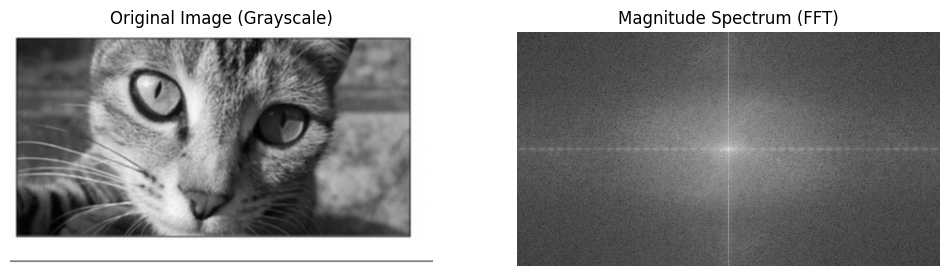

In [21]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
f = np.fft.fft2(img_gray)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20 * np.log(np.abs(fshift))

plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Image (Grayscale)')
plt.axis('off')

plt.subplot(122)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum (FFT)')
plt.axis('off')
plt.show()

### 1.2 Applying Inverse Fast Fourier transform (IFFT)

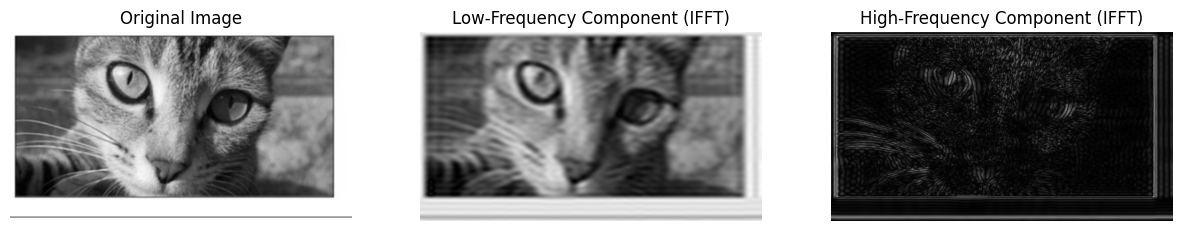

In [24]:
rows, cols = img_gray.shape

crow, ccol = rows // 2, cols // 2

mask_size = 30

mask_low = np.zeros((rows, cols), dtype=np.uint8)
mask_low[crow - mask_size:crow + mask_size, ccol - mask_size:ccol + mask_size] = 1

mask_high = np.ones((rows, cols), dtype=np.uint8)
mask_high[crow - mask_size:crow + mask_size, ccol - mask_size:ccol + mask_size] = 0

fshift_low = fshift * mask_low

fshift_high = fshift * mask_high

f_ishift_low = np.fft.ifftshift(fshift_low)

img_back_low = np.fft.ifft2(f_ishift_low)
img_back_low = np.abs(img_back_low)
img_back_low = np.uint8(cv2.normalize(img_back_low, None, 0, 255, cv2.NORM_MINMAX))

f_ishift_high = np.fft.ifftshift(fshift_high)

img_back_high = np.fft.ifft2(f_ishift_high)
img_back_high = np.abs(img_back_high)
img_back_high = np.uint8(cv2.normalize(img_back_high, None, 0, 255, cv2.NORM_MINMAX))

plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(132)
plt.imshow(img_back_low, cmap='gray')
plt.title('Low-Frequency Component (IFFT)')
plt.axis('off')

plt.subplot(133)
plt.imshow(img_back_high, cmap='gray')
plt.title('High-Frequency Component (IFFT)')
plt.axis('off')

plt.show()

## 2 LPF

In [29]:
img = cv2.imread('penguine.jpg', 0)
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

f_transform = np.fft.fft2(img)
f_shift = np.fft.fftshift(f_transform)

x = np.linspace(-ccol, cols - ccol - 1, cols)
y = np.linspace(-crow, rows - crow - 1, rows)
X, Y = np.meshgrid(x, y)
D = np.sqrt(X**2 + Y**2)

a. Ideal Low-Pass Filter (ILPF)

In [30]:
D0 = 30
mask_ideal = np.zeros((rows, cols), np.float32)
mask_ideal[D <= D0] = 1

f_ideal = f_shift * mask_ideal

b. Gaussian Low-Pass Filter (GLPF)

In [31]:
mask_gaussian = np.exp(-(D**2) / (2 * (D0**2)))

f_gaussian = f_shift * mask_gaussian

c. Butterworth Low-Pass Filter (BLPF)

In [32]:
n = 2
mask_butterworth = 1 / (1 + (D / D0)**(2 * n))

f_butterworth = f_shift * mask_butterworth

Plot >>

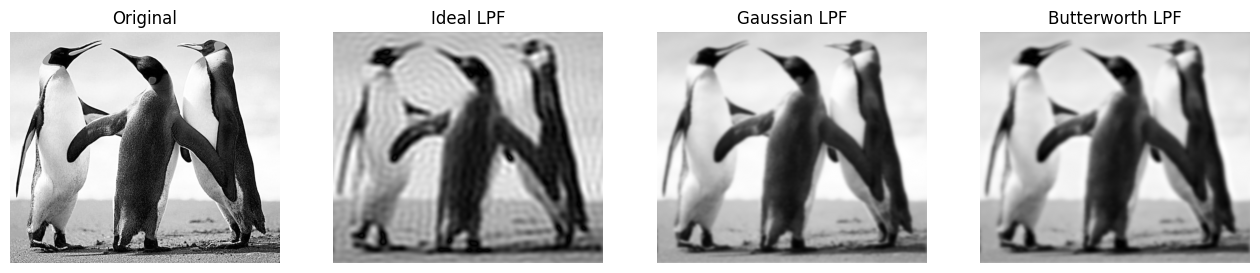

In [33]:
def to_image(f_data):
    f_ishift = np.fft.ifftshift(f_data)
    img_back = np.fft.ifft2(f_ishift)
    return np.abs(img_back)

img_ideal = to_image(f_ideal)
img_gaussian = to_image(f_gaussian)
img_butterworth = to_image(f_butterworth)

titles = ['Original', 'Ideal LPF', 'Gaussian LPF', 'Butterworth LPF']
images = [img, img_ideal, img_gaussian, img_butterworth]

plt.figure(figsize=(16, 10))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

## 3 HPF

In [47]:
img = cv2.imread('cameraman.jpg', 0)

In [48]:
D0 = 30
mask_ihpf = np.ones((rows, cols), np.float32)
mask_ihpf[D <= D0] = 0

f_ihpf = f_shift * mask_ihpf

In [49]:
mask_ghpf = 1 - np.exp(-(D**2) / (2 * (D0**2)))

f_ghpf = f_shift * mask_ghpf

In [50]:
n = 2
# Adding small epsilon to D to avoid division by zero at the center
mask_bhpf = 1 / (1 + (D0 / (D + 1e-5))**(2 * n))

f_bhpf = f_shift * mask_bhpf

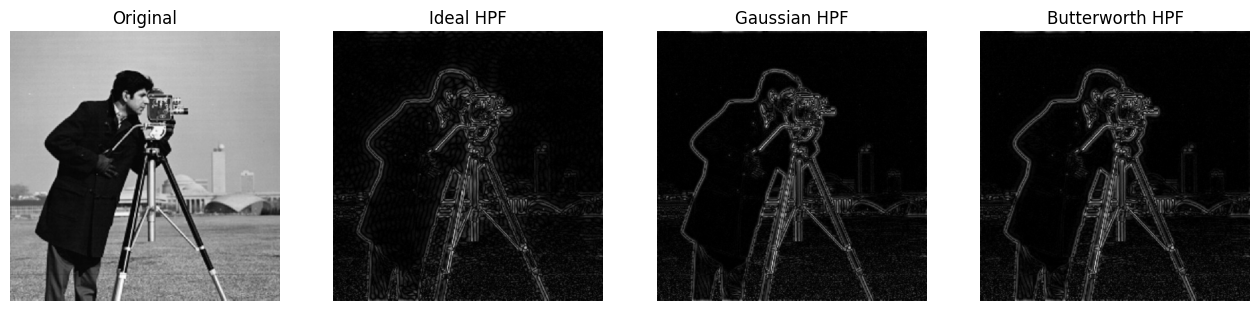

In [51]:
def to_image(f_data):
    f_ishift = np.fft.ifftshift(f_data)
    img_back = np.fft.ifft2(f_ishift)
    return np.abs(img_back)

img_ihpf = to_image(f_ihpf)
img_ghpf = to_image(f_ghpf)
img_bhpf = to_image(f_bhpf)

titles = ['Original', 'Ideal HPF', 'Gaussian HPF', 'Butterworth HPF']
images = [img, img_ihpf, img_ghpf, img_bhpf]

plt.figure(figsize=(16, 10))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

## 4 Gaussian Smoothening and Homomorphic Filtering

In [54]:
img = cv2.imread('cameraman.jpg', 0)

### 4.1 Gaussian Smoothening

In [58]:
img_smoothed = cv2.GaussianBlur(img, (5, 5), 0)

# Log Trans
img_log = np.log1p(np.array(img_smoothed, dtype="float"))

# Freq Domn
rows, cols = img.shape
f_transform = np.fft.fft2(img_log)
f_shift = np.fft.fftshift(f_transform)

### 4.2 Homomorphic Filtering

In [59]:
gH, gL, c, D0 = 1.2, 0.5, 1, 30

crow, ccol = rows // 2, cols // 2
x = np.linspace(-ccol, cols - ccol - 1, cols)
y = np.linspace(-crow, rows - crow - 1, rows)
X, Y = np.meshgrid(x, y)
D_sq = X**2 + Y**2
h_filter = (gH - gL) * (1 - np.exp(-c * D_sq / (D0**2))) + gL

f_filtered = f_shift * h_filter
f_ishift = np.fft.ifftshift(f_filtered)
img_ifft = np.fft.ifft2(f_ishift)

img_homomorphic = np.real(np.exp(img_ifft) - 1)

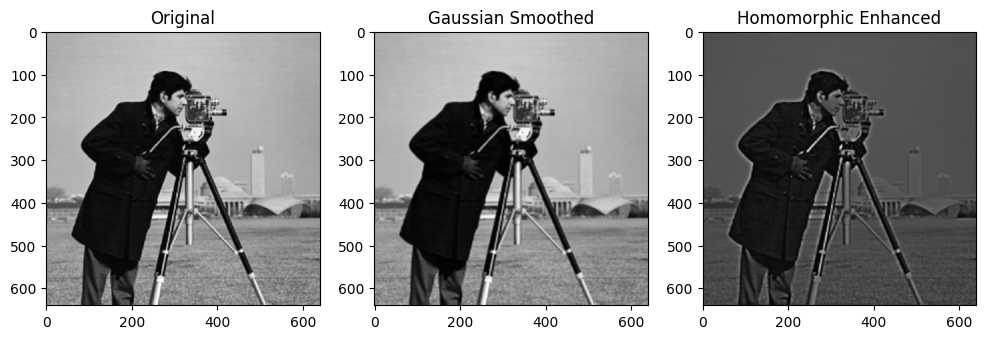

In [61]:
img_homomorphic = cv2.normalize(img_homomorphic, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.subplot(131), plt.imshow(img, cmap='gray'), plt.title('Original')
plt.subplot(132), plt.imshow(img_smoothed, cmap='gray'), plt.title('Gaussian Smoothed')
plt.subplot(133), plt.imshow(img_homomorphic, cmap='gray'), plt.title('Homomorphic Enhanced')
plt.show()